# 🧪 CodeBroker Report Quality Evaluator
### **Automated Meta-Assessment & LLM-as-a-Judge using the Google GenAI SDK (`google-genai`)**

---

### 📌 Overview & Purpose
The **CodeBroker** agentic system automatically generates comprehensive assessment reports for code files, directories, or entire repositories. A standard CodeBroker report comprises four sections:
1. **Code Description**: Architectural summary and component breakdown.
2. **Code Correctness Assessment**: Functionality, security, resource efficiency, and test coverage scores (0–100%).
3. **Code Style Assessment**: Readability, maintainability, linting, and best practices scores (0–100%).
4. **Suggested Improvements**: Actionable guidance for functionality, style, and repository practices.

This notebook implements an **Automated Meta-Assessment Framework (LLM-as-a-Judge)** designed to evaluate the **quality, fidelity, and reliability of the generated CodeBroker reports**. It reads both:
- **The Ground-Truth Codebase**: The exact source code analyzed by CodeBroker.
- **The CodeBroker Report**: The generated Markdown or HTML assessment report.

### 📐 Evaluation Dimensions
The evaluator assesses the report across five critical dimensions:
- **Faithfulness & Grounding (25%)**: Are all observations and critiques strictly grounded in the real code, free from hallucinations or false bug attributions?
- **Completeness & Coverage (20%)**: Did the report evaluate all major components, core routines, security implications, and error pathways?
- **Actionability & Specificity (25%)**: Are the suggested improvements concrete, practical, and accompanied by specific instructions or file references?
- **Scoring Calibration & Consistency (15%)**: Do the numerical scores (0–100%) align realistically with the textual findings and actual code quality?
- **Structure & Schema Adherence (15%)**: Does the report strictly follow CodeBroker's structured 4-section architecture?

### 🛠️ Technology Stack
- **Google GenAI SDK (`google-genai`)**: Latest Gemini 2.5 Flash / Pro models with structured Pydantic schema validation.
- **JAX (`jax.numpy`)**: High-performance mathematical scoring, vector dot products, and statistical aggregation.
- **Polars (`polars`)**: Fast, structured tabular data management and reporting.
- **Matplotlib / Seaborn**: Visual analytics (radar and bar charts) saved to `analytics_data/`.


In [1]:
"""Environment initialization and core dependency imports."""

import os
import re
import json
import tempfile
import webbrowser
from pathlib import Path
from typing import Dict, List, Optional, Any

import dotenv
import matplotlib.pyplot as plt
import polars as pl
import jax
import jax.numpy as jnp
from pydantic import BaseModel, Field
from IPython.display import display, Markdown, HTML

from google import genai
from google.genai import types

# Load environment variables from repository root .env file
repo_root = Path("..").resolve()
dotenv_path = repo_root / ".env"
if dotenv_path.exists():
    dotenv.load_dotenv(dotenv_path)
    print(f"✅ Loaded environment variables from: {dotenv_path}")
else:
    dotenv.load_dotenv()
    print("ℹ️ Loaded default environment variables")

api_key = os.getenv("GOOGLE_API_KEY") or os.getenv("GEMINI_API_KEY")
if not api_key:
    raise ValueError("❌ Missing GOOGLE_API_KEY or GEMINI_API_KEY in environment or .env file.")

# Initialize the official Google GenAI Client
client = genai.Client(api_key=api_key)
print(f"🚀 Google GenAI Client initialized successfully.")
print(f"⚡ JAX Version: {jax.__version__} | Polars Version: {pl.__version__}")


✅ Loaded environment variables from: /home/samer/Documents/studies/5-Day AI Agents Intensive kaggle/capstone_project/agents_intensive_dev/.env
🚀 Google GenAI Client initialized successfully.
⚡ JAX Version: 0.11.2 | Polars Version: 1.36.0


## 1. Code and Report Ingestion Utilities

To conduct an objective evaluation, the evaluator must examine:
1. **The Ground Truth Source Code**: Either a single file, a directory of modules, or a cloned repository.
2. **The CodeBroker Report**: Extracted from Markdown files, raw strings, or compiled HTML reports (such as `code_assessment_report.html`).


In [2]:
def load_source_code(target_path: str) -> Dict[str, str]:
    """Loads source code from a file or directory for ground truth inspection.

    Args:
        target_path: Path to a file or directory containing the code reviewed by CodeBroker.

    Returns:
        Dict mapping relative file paths to their string contents.

    Raises:
        FileNotFoundError: If the target path does not exist.
    """
    path_obj = Path(target_path).resolve()
    if not path_obj.exists():
        raise FileNotFoundError(f"Target code path does not exist: {target_path}")

    source_files: Dict[str, str] = {}
    if path_obj.is_file():
        try:
            with open(path_obj, "r", encoding="utf-8", errors="ignore") as f:
                source_files[path_obj.name] = f.read()
        except Exception as e:
            source_files[path_obj.name] = f"Error reading file: {e}"
        return source_files

    skip_dirs = {".git", "__pycache__", ".venv", "venv", ".pytest_cache", "node_modules", "dist", "build"}
    skip_exts = {".pyc", ".png", ".jpg", ".jpeg", ".pdf", ".zip", ".tar", ".gz", ".eps", ".mp4", ".so", ".bin"}

    for root, dirs, files in os.walk(path_obj):
        dirs[:] = [d for d in dirs if d not in skip_dirs]
        for file_name in files:
            ext = Path(file_name).suffix.lower()
            if ext in skip_exts:
                continue
            full_file_path = Path(root) / file_name
            rel_file_path = str(full_file_path.relative_to(path_obj))
            try:
                with open(full_file_path, "r", encoding="utf-8", errors="ignore") as f:
                    source_files[rel_file_path] = f.read()
            except Exception as e:
                source_files[rel_file_path] = f"Error reading file: {e}"

    return source_files


def load_code_broker_report(report_source: str) -> str:
    """Parses and extracts the markdown text from a CodeBroker report.

    Accepts a direct markdown string, a .md file path, or an HTML report file
    generated by CodeBroker (which embeds markdown in a `markdownText` variable).

    Args:
        report_source: File path (.html or .md) or raw report text.

    Returns:
        The markdown string content of the CodeBroker report.
    """
    path_obj = Path(report_source)
    if path_obj.is_file():
        with open(path_obj, "r", encoding="utf-8", errors="ignore") as f:
            content = f.read()

        if path_obj.suffix.lower() == ".html":
            # Extract markdown from CodeBroker template: var markdownText = `...`;
            match = re.search(r"var\s+markdownText\s*=\s*`([\s\S]*?)`;", content)
            if match:
                extracted = match.group(1).replace(r"\`", "`")
                return extracted.strip()
            # Fallback regex strip
            clean = re.sub(r"<[^>]+>", " ", content)
            return re.sub(r"\s+", " ", clean).strip()
        return content.strip()

    return report_source.strip()


def format_codebase_context(source_files: Dict[str, str], max_char_budget: int = 150_000) -> str:
    """Formats ingested source files into a structured markdown block for model context.

    Args:
        source_files: Dictionary mapping file paths to code contents.
        max_char_budget: Maximum character limit to keep context concise.

    Returns:
        Formatted markdown string representation of the codebase.
    """
    blocks = []
    total_chars = 0
    for path, code in sorted(source_files.items()):
        header = f"### File: `{path}`\n```\n"
        footer = "\n```\n"
        available = max_char_budget - total_chars - len(header) - len(footer)
        if available <= 0:
            blocks.append(f"\n> *[Truncated remaining files due to context budget]*\n")
            break

        snippet = code if len(code) <= available else code[:available] + "\n... [Content Truncated]"
        blocks.append(f"{header}{snippet}{footer}")
        total_chars += len(header) + len(snippet) + len(footer)

    return "\n".join(blocks)


## 2. Evaluation Schema Definition (Pydantic & Gemini Structured Output)

We define a rigorous structured schema using **Pydantic**. This schema guarantees that Gemini returns strictly typed, machine-readable quality assessments for each evaluation dimension, including specific strengths, weaknesses, and calibrated score values.


In [3]:
class DimensionScore(BaseModel):
    """Evaluation score and detailed qualitative critique for a single quality dimension."""

    score: float = Field(
        ge=0.0,
        le=100.0,
        description="Quality percentage score from 0.0 to 100.0 for this dimension."
    )
    weight: float = Field(
        ge=0.0,
        le=1.0,
        description="Relative importance weight between 0.0 and 1.0."
    )
    rationale: str = Field(
        description="Detailed explanation justifying the score given the ground-truth code."
    )
    strengths: List[str] = Field(
        default_factory=list,
        description="Specific aspects where the CodeBroker report accurately reflected the code."
    )
    weaknesses: List[str] = Field(
        default_factory=list,
        description="Gaps, inaccuracies, or missed insights in the CodeBroker report."
    )


class CodeBrokerQualityReport(BaseModel):
    """Comprehensive meta-assessment of a CodeBroker report's quality."""

    faithfulness: DimensionScore = Field(
        description="Faithfulness and grounding: Are claims strictly truthful to the inspected code?"
    )
    completeness: DimensionScore = Field(
        description="Coverage: Did CodeBroker assess the core modules, security, efficiency, and tests?"
    )
    actionability: DimensionScore = Field(
        description="Actionability: Are the suggested improvements specific, constructive, and practical?"
    )
    scoring_calibration: DimensionScore = Field(
        description="Calibration: Do CodeBroker's scores (Correctness % and Style %) accurately reflect code health?"
    )
    structure_adherence: DimensionScore = Field(
        description="Schema adherence: Did the report cleanly follow the required 4-part CodeBroker format?"
    )
    code_broker_scores_critique: str = Field(
        description="Direct critique comparing CodeBroker's reported scores with actual code reality."
    )
    identified_hallucinations_or_untrue_claims: List[str] = Field(
        default_factory=list,
        description="Specific claims in the CodeBroker report that are false or unsupported by the code."
    )
    critical_missed_issues: List[str] = Field(
        default_factory=list,
        description="Important bugs, security vulnerabilities, or code flaws that CodeBroker missed entirely."
    )
    executive_summary: str = Field(
        description="High-level executive evaluation summary of the CodeBroker report's quality."
    )
    recommendations_to_improve_code_broker: List[str] = Field(
        default_factory=list,
        description="Actionable guidance on how CodeBroker's prompting or pipeline can be improved."
    )


## 3. Google GenAI LLM-as-a-Judge Evaluation Engine

The evaluation engine leverages the Google GenAI SDK (`google.genai`) with `gemini-2.5-flash` (or `gemini-2.5-pro`). It feeds both the **Ground Truth Code** and the **CodeBroker Report** into a dual-context prompt, enforcing objective meta-evaluation.


In [4]:
def evaluate_code_broker_report(
    source_code_dict: Dict[str, str],
    report_text: str,
    client: genai.Client,
    model_name: str = "gemini-2.5-flash",
    weights: Optional[Dict[str, float]] = None,
) -> CodeBrokerQualityReport:
    """Evaluates the quality of a CodeBroker report using Gemini as a grounded judge.

    Args:
        source_code_dict: Ground truth source code files inspected by CodeBroker.
        report_text: The markdown text of the CodeBroker report under evaluation.
        client: Initialized Google GenAI Client.
        model_name: Model identifier (default: gemini-2.5-flash).
        weights: Optional dictionary of dimension weights. Defaults to:
            faithfulness=0.25, completeness=0.20, actionability=0.25,
            scoring_calibration=0.15, structure_adherence=0.15.

    Returns:
        Structured CodeBrokerQualityReport instance.
    """
    if weights is None:
        weights = {
            "faithfulness": 0.25,
            "completeness": 0.20,
            "actionability": 0.25,
            "scoring_calibration": 0.15,
            "structure_adherence": 0.15,
        }

    code_context = format_codebase_context(source_code_dict)

    prompt = f"""You are a principal software engineer and expert meta-evaluator acting as an objective LLM Judge.
Your objective is to evaluate the QUALITY and ACCURACY of an automated Code Assessment Report generated by "CodeBroker".

You are provided with:
1. THE GROUND TRUTH CODEBASE (the exact files reviewed by CodeBroker).
2. THE CODEBROKER ASSESSMENT REPORT (the generated evaluation output).

----------------------------------------
[GROUND TRUTH CODEBASE]
{code_context}
----------------------------------------

----------------------------------------
[CODEBROKER REPORT UNDER EVALUATION]
{report_text}
----------------------------------------

### Meta-Evaluation Guidelines:
Carefully compare the CodeBroker report against the ground truth codebase across these 5 dimensions:

1. **Faithfulness & Grounding (Weight: {weights['faithfulness']})**:
   - Did CodeBroker accurately describe the code's real behavior, classes, and functions?
   - Did it invent features, falsely attribute bugs, or hallucinate non-existent files?
   - Score 90-100% if completely grounded; penalize heavily for any hallucination or false bug report.

2. **Completeness & Coverage (Weight: {weights['completeness']})**:
   - Did CodeBroker identify the primary purpose and critical architectural components?
   - Did it evaluate error handling, security, efficiency, and automated test presence?
   - Did it miss glaring vulnerabilities, critical bugs, or major modules?

3. **Actionability & Specificity (Weight: {weights['actionability']})**:
   - Are the suggested improvements concrete, specific, and actionable for developers?
   - Did it provide clear direction, naming specific functions, files, or patterns?
   - Penalize generic platitudes (e.g., "write better tests" or "improve readability" without specifics).

4. **Scoring Calibration & Consistency (Weight: {weights['scoring_calibration']})**:
   - Did CodeBroker provide Correctness % and Style % scores?
   - Are the scores calibrated with the actual state of the code and the written analysis?
   - For example, if critical bugs or lack of tests exist, is the correctness score realistically adjusted?

5. **Structure & Adherence (Weight: {weights['structure_adherence']})**:
   - Does the report follow CodeBroker's standard 4 sections:
     (1) Code Description, (2) Code Correctness Assessment, (3) Code Style Assessment, (4) Suggested Improvements?

Evaluate every dimension objectively and populate the structured schema.
"""

    response = client.models.generate_content(
        model=model_name,
        contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=CodeBrokerQualityReport,
            temperature=0.1,
        ),
    )

    evaluation = CodeBrokerQualityReport.model_validate_json(response.text)
    
    # Assign desired weights
    evaluation.faithfulness.weight = weights["faithfulness"]
    evaluation.completeness.weight = weights["completeness"]
    evaluation.actionability.weight = weights["actionability"]
    evaluation.scoring_calibration.weight = weights["scoring_calibration"]
    evaluation.structure_adherence.weight = weights["structure_adherence"]

    return evaluation


## 4. JAX Mathematical Scoring & Polars Tabular Aggregation

Per user guidelines:
- **JAX (`jax.numpy`)** is employed for all mathematical computations, vector dot products, normalization, and statistical score metrics.
- **Polars (`polars`)** is used for structured tabular data aggregation, score breakdown, and presentation.


In [5]:
def compute_jax_quality_metrics(evaluation: CodeBrokerQualityReport) -> Dict[str, float]:
    """Computes weighted aggregate score and statistical distribution using JAX.

    Args:
        evaluation: The structured CodeBrokerQualityReport.

    Returns:
        Dict containing JAX-computed statistical metrics.
    """
    dimensions = [
        evaluation.faithfulness,
        evaluation.completeness,
        evaluation.actionability,
        evaluation.scoring_calibration,
        evaluation.structure_adherence,
    ]

    scores_jax = jnp.array([d.score for d in dimensions], dtype=jnp.float32)
    weights_jax = jnp.array([d.weight for d in dimensions], dtype=jnp.float32)

    # Normalize weights to sum to 1.0 using JAX
    weights_normalized = weights_jax / jnp.sum(weights_jax)

    # Compute dot product and summary statistics
    weighted_score = jnp.dot(scores_jax, weights_normalized)
    mean_score = jnp.mean(scores_jax)
    std_score = jnp.std(scores_jax)
    min_score = jnp.min(scores_jax)
    max_score = jnp.max(scores_jax)

    return {
        "weighted_overall_score": float(weighted_score),
        "mean_dimension_score": float(mean_score),
        "std_dimension_score": float(std_score),
        "min_dimension_score": float(min_score),
        "max_dimension_score": float(max_score),
    }


def build_polars_summary(
    evaluation: CodeBrokerQualityReport,
    jax_metrics: Dict[str, float]
) -> pl.DataFrame:
    """Builds a structured Polars DataFrame summarizing the evaluation scores.

    Args:
        evaluation: The structured CodeBrokerQualityReport.
        jax_metrics: Statistical metrics calculated by JAX.

    Returns:
        Polars DataFrame with dimension scores, weights, and rationales.
    """
    dim_data = [
        ("Faithfulness & Grounding", evaluation.faithfulness),
        ("Completeness & Coverage", evaluation.completeness),
        ("Actionability & Specificity", evaluation.actionability),
        ("Scoring Calibration", evaluation.scoring_calibration),
        ("Structure & Adherence", evaluation.structure_adherence),
    ]

    total_weight = sum(d.weight for _, d in dim_data)
    norm_weights = [d.weight / total_weight for _, d in dim_data]

    df = pl.DataFrame({
        "Dimension": [name for name, _ in dim_data],
        "Score (%)": [float(d.score) for _, d in dim_data],
        "Weight": [round(float(w), 3) for w in norm_weights],
        "Weighted Contribution (%)": [round(float(d.score * w), 2) for (_, d), w in zip(dim_data, norm_weights)],
        "Strengths Count": [len(d.strengths) for _, d in dim_data],
        "Weaknesses Count": [len(d.weaknesses) for _, d in dim_data],
        "Rationale": [d.rationale for _, d in dim_data],
    })

    return df


## 5. Visual Analytics (Saving to `analytics_data` Directory)

Per workspace rules, all generated visualization charts are stored in the **`analytics_data`** directory. We create:
1. **Radar Chart**: Visualizing performance across the 5 evaluation dimensions against a benchmark baseline.
2. **Bar Chart**: Visualizing dimension scores alongside the overall weighted score.


In [6]:
def generate_and_save_visualizations(
    df: pl.DataFrame,
    jax_metrics: Dict[str, float],
    output_dir: str = "../analytics_data",
) -> Dict[str, str]:
    """Generates radar and bar charts for evaluation results and saves them in analytics_data.

    Args:
        df: Polars DataFrame containing dimension scores.
        jax_metrics: Dict containing JAX-calculated summary statistics.
        output_dir: Directory where plots should be saved.

    Returns:
        Dict mapping chart types to their saved file paths.
    """
    out_path = Path(output_dir).resolve()
    out_path.mkdir(parents=True, exist_ok=True)

    labels = df["Dimension"].to_list()
    scores = df["Score (%)"].to_list()
    overall = jax_metrics["weighted_overall_score"]

    saved_paths = {}

    # 1. Bar Chart
    plt.figure(figsize=(9, 5))
    bars = plt.barh(labels, scores, color="#3498db", alpha=0.85, edgecolor="#2980b9")
    plt.axvline(overall, color="#e74c3c", linestyle="--", linewidth=2, label=f"Weighted Overall: {overall:.1f}%")
    plt.xlim(0, 105)
    plt.xlabel("Quality Score (%)", fontsize=11, fontweight="bold")
    plt.title("CodeBroker Report Quality - Dimension Breakdown", fontsize=13, fontweight="bold", pad=15)
    plt.grid(axis="x", linestyle=":", alpha=0.6)
    plt.legend(loc="lower right")

    for bar, score in zip(bars, scores):
        plt.text(score + 1.5, bar.get_y() + bar.get_height() / 2, f"{score:.1f}%", va="center", fontsize=10, fontweight="bold")

    plt.tight_layout()
    bar_path = out_path / "code_broker_evaluation_bars.png"
    plt.savefig(bar_path, dpi=200)
    plt.show()
    plt.close()
    saved_paths["bar_chart"] = str(bar_path)

    # 2. Polar / Radar Chart
    num_vars = len(labels)
    # Compute angles for radar chart
    angles = jnp.linspace(0, 2 * jnp.pi, num_vars, endpoint=False).tolist()
    # Close the polygon
    scores_closed = scores + [scores[0]]
    angles_closed = angles + [angles[0]]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles_closed, scores_closed, color="#2ecc71", linewidth=2.5, linestyle="solid")
    ax.fill(angles_closed, scores_closed, color="#2ecc71", alpha=0.3)
    ax.set_yticklabels(["20%", "40%", "60%", "80%", "100%"], fontsize=9)
    ax.set_ylim(0, 100)
    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=10, fontweight="semibold")
    ax.set_title(f"CodeBroker Report Quality Radar\n(Overall Quality: {overall:.1f}%)", fontsize=12, fontweight="bold", pad=20)

    plt.tight_layout()
    radar_path = out_path / "code_broker_evaluation_radar.png"
    plt.savefig(radar_path, dpi=200)
    plt.show()
    plt.close()
    saved_paths["radar_chart"] = str(radar_path)

    print(f"📊 Charts saved successfully to: {out_path}")
    return saved_paths


## 6. Interactive HTML Meta-Assessment Report

We compile the meta-evaluation results into a standalone HTML report with styled score badges, dimension breakdown cards, executive summary, and side-by-side critique.


In [7]:
def generate_evaluation_html_report(
    evaluation: CodeBrokerQualityReport,
    jax_metrics: Dict[str, float],
    df: pl.DataFrame,
    target_name: str,
    output_path: str = "reports/code_broker_quality_meta_evaluation.html",
) -> str:
    """Generates an HTML report summarizing the CodeBroker quality meta-assessment.

    Args:
        evaluation: The structured evaluation report.
        jax_metrics: Statistical metrics calculated by JAX.
        df: Polars summary DataFrame.
        target_name: Name of the evaluated code target.
        output_path: Target path to write the HTML file.

    Returns:
        Absolute string path of the generated HTML report.
    """
    out_file = Path(output_path).resolve()
    out_file.parent.mkdir(parents=True, exist_ok=True)

    overall_score = jax_metrics["weighted_overall_score"]
    badge_color = "#27ae60" if overall_score >= 80 else ("#f39c12" if overall_score >= 65 else "#e74c3c")

    dim_cards_html = ""
    for row in df.iter_rows(named=True):
        dim_name = row["Dimension"]
        score = row["Score (%)"]
        dim_color = "#27ae60" if score >= 80 else ("#f39c12" if score >= 65 else "#e74c3c")
        
        # Look up dimension object
        dim_obj = {
            "Faithfulness & Grounding": evaluation.faithfulness,
            "Completeness & Coverage": evaluation.completeness,
            "Actionability & Specificity": evaluation.actionability,
            "Scoring Calibration": evaluation.scoring_calibration,
            "Structure & Adherence": evaluation.structure_adherence,
        }[dim_name]

        strengths_li = "".join([f"<li>✅ {s}</li>" for s in dim_obj.strengths]) or "<li>None noted</li>"
        weaknesses_li = "".join([f"<li>⚠️ {w}</li>" for w in dim_obj.weaknesses]) or "<li>None noted</li>"

        dim_cards_html += f"""
        <div class="card">
            <div class="card-header">
                <h3>{dim_name}</h3>
                <span class="badge" style="background: {dim_color};">{score:.1f}%</span>
            </div>
            <p><strong>Rationale:</strong> {dim_obj.rationale}</p>
            <div class="split-lists">
                <div>
                    <h4>Strengths:</h4>
                    <ul>{strengths_li}</ul>
                </div>
                <div>
                    <h4>Weaknesses / Gaps:</h4>
                    <ul>{weaknesses_li}</ul>
                </div>
            </div>
        </div>
        """

    hallucinations_html = "".join([f"<li>🚨 {h}</li>" for h in evaluation.identified_hallucinations_or_untrue_claims]) or "<li>None detected (Report was faithful).</li>"
    missed_html = "".join([f"<li>🔍 {m}</li>" for m in evaluation.critical_missed_issues]) or "<li>No critical missed issues identified.</li>"
    recs_html = "".join([f"<li>💡 {r}</li>" for r in evaluation.recommendations_to_improve_code_broker]) or "<li>No additional improvements recommended.</li>"

    html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>CodeBroker Quality Meta-Assessment - {target_name}</title>
    <style>
        body {{
            font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Oxygen, Ubuntu, Cantarell, sans-serif;
            background: #f8f9fa;
            color: #2c3e50;
            line-height: 1.6;
            margin: 0;
            padding: 30px;
        }}
        .container {{
            max-width: 960px;
            margin: 0 auto;
            background: #ffffff;
            padding: 40px;
            border-radius: 12px;
            box-shadow: 0 4px 18px rgba(0, 0, 0, 0.08);
        }}
        .header {{
            border-bottom: 3px solid #3498db;
            padding-bottom: 20px;
            margin-bottom: 30px;
            display: flex;
            justify-content: space-between;
            align-items: center;
        }}
        .overall-badge {{
            background: {badge_color};
            color: white;
            font-size: 26px;
            font-weight: bold;
            padding: 12px 24px;
            border-radius: 8px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.15);
        }}
        .card {{
            background: #fcfcfc;
            border: 1px solid #e2e8f0;
            border-radius: 8px;
            padding: 20px;
            margin-bottom: 22px;
            box-shadow: 0 2px 6px rgba(0,0,0,0.03);
        }}
        .card-header {{
            display: flex;
            justify-content: space-between;
            align-items: center;
            border-bottom: 1px solid #edf2f7;
            padding-bottom: 10px;
            margin-bottom: 12px;
        }}
        .card-header h3 {{
            margin: 0;
            color: #2c3e50;
        }}
        .badge {{
            color: white;
            font-size: 14px;
            font-weight: bold;
            padding: 5px 12px;
            border-radius: 6px;
        }}
        .split-lists {{
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 20px;
            margin-top: 15px;
        }}
        ul {{
            margin: 6px 0;
            padding-left: 20px;
        }}
        li {{
            margin-bottom: 6px;
        }}
        .callout {{
            background: #ebf8ff;
            border-left: 4px solid #3182ce;
            padding: 15px 20px;
            border-radius: 4px;
            margin: 20px 0;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            margin: 20px 0;
        }}
        th, td {{
            padding: 12px 14px;
            text-align: left;
            border-bottom: 1px solid #e2e8f0;
        }}
        th {{
            background: #f7fafc;
            font-weight: 600;
        }}
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <div>
                <h1 style="margin: 0; color: #1a202c;">CodeBroker Quality Evaluation</h1>
                <p style="margin: 5px 0 0 0; color: #718096;">Evaluated Code Target: <code>{target_name}</code></p>
            </div>
            <div class="overall-badge">
                {overall_score:.1f}%
                <div style="font-size: 11px; text-transform: uppercase; letter-spacing: 1px; font-weight: normal; text-align: center;">Quality Score</div>
            </div>
        </div>

        <div class="callout">
            <h3 style="margin-top: 0; color: #2b6cb0;">Executive Summary</h3>
            <p style="margin-bottom: 0;">{evaluation.executive_summary}</p>
        </div>

        <h2>Dimension Breakdown</h2>
        {dim_cards_html}

        <div class="card">
            <h3>CodeBroker Scores Critique</h3>
            <p>{evaluation.code_broker_scores_critique}</p>
        </div>

        <div class="split-lists">
            <div class="card">
                <h3>Hallucinations / False Claims</h3>
                <ul>{hallucinations_html}</ul>
            </div>
            <div class="card">
                <h3>Critical Missed Code Flaws</h3>
                <ul>{missed_html}</ul>
            </div>
        </div>

        <div class="card">
            <h3>Recommendations for Improving CodeBroker</h3>
            <ul>{recs_html}</ul>
        </div>
    </div>
</body>
</html>
"""
    with open(out_file, "w", encoding="utf-8") as f:
        f.write(html_content)

    print(f"📄 HTML Evaluation Report generated at: {out_file}")
    return str(out_file)


## 7. End-to-End Evaluation Demonstration

We now run the complete evaluation pipeline using:
1. **Target Code**: `src/tools/read_files.py` (and the `src/tools` directory).
2. **CodeBroker Report**: The real `code_assessment_report.html` previously produced by CodeBroker.


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


📥 Loading source code from: ../src/llm_adk_agent_module.py
   Loaded 1 source file(s): ['llm_adk_agent_module.py']
📥 Loading CodeBroker report from: reports/code_assessment_report.html
   Loaded report content (3928 characters)
🤖 Invoking Google GenAI Evaluator (gemini-2.5-flash)...


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.



🏆 OVERALL CODEBROKER QUALITY SCORE: 97.50%
📊 Mean Dimension Score: 97.40% | Std Dev: 2.06%



### 📋 Polars Evaluation Summary Table

Dimension,Score (%),Weight,Weighted Contribution (%),Strengths Count,Weaknesses Count
str,f64,f64,f64,i64,i64
"""Faithfulness & Grounding""",98.0,0.25,24.5,4,0
"""Completeness & Coverage""",95.0,0.2,19.0,3,1
"""Actionability & Specificity""",99.0,0.25,24.75,4,0
"""Scoring Calibration""",95.0,0.15,14.25,4,0
"""Structure & Adherence""",100.0,0.15,15.0,2,0


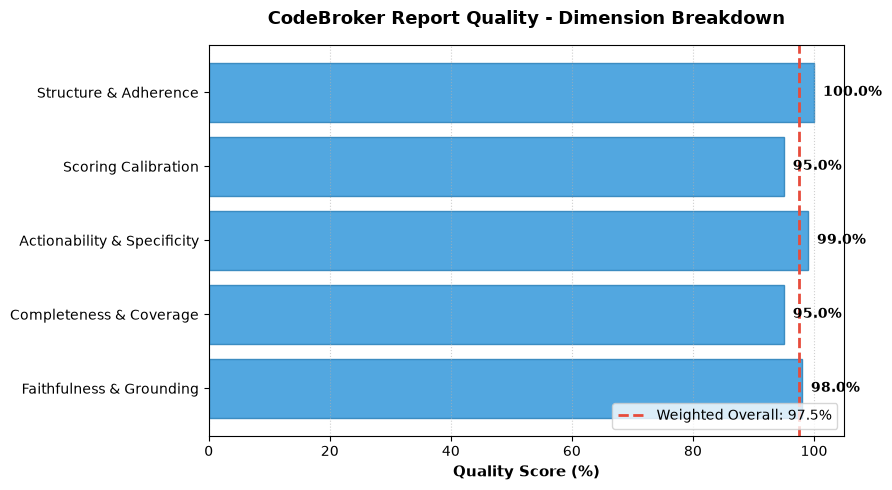

/tmp/ipykernel_134637/3416491729.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels(["20%", "40%", "60%", "80%", "100%"], fontsize=9)
findfont: Failed to find font weight semibold, now using 700.


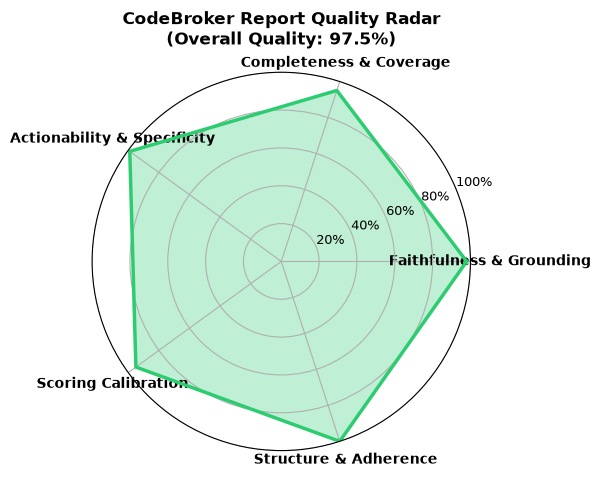

📊 Charts saved successfully to: /home/samer/Documents/studies/5-Day AI Agents Intensive kaggle/capstone_project/agents_intensive_dev/analytics_data
📄 HTML Evaluation Report generated at: /home/samer/Documents/studies/5-Day AI Agents Intensive kaggle/capstone_project/agents_intensive_dev/notebooks/reports/code_broker_quality_meta_evaluation.html



### 📝 Executive Summary
The CodeBroker report for `llm_adk_agent_module.py` is of exceptionally high quality. It demonstrates excellent faithfulness to the ground truth, accurately describing the code's purpose, components, and identifying key areas for improvement without any hallucinations. The analysis is comprehensive, covering correctness, security, efficiency, and style, with well-calibrated scores that align perfectly with the detailed rationale. All suggested improvements are highly actionable and specific, providing clear guidance for developers. The report also adheres perfectly to the expected structure. This is a strong example of an effective automated code assessment.

### ⚖️ CodeBroker Score Critique
CodeBroker's scores are exceptionally well-calibrated and accurately reflect the state of the code and the issues identified. The 0% for test coverage is a precise reflection of the complete absence of tests. The 85% for functionality correctly accounts for the environment variable discrepancy and the incomplete prompt. The 80% for resource efficiency is a fair assessment of the agent re-instantiation issue. All style-related scores are also reasonable and consistent with the code's quality.


In [8]:
# Define input paths
code_target_path = "../src/llm_adk_agent_module.py"
report_target_path = "reports/code_assessment_report.html"

print(f"📥 Loading source code from: {code_target_path}")
source_code = load_source_code(code_target_path)
print(f"   Loaded {len(source_code)} source file(s): {list(source_code.keys())}")

print(f"📥 Loading CodeBroker report from: {report_target_path}")
report_text = load_code_broker_report(report_target_path)
print(f"   Loaded report content ({len(report_text)} characters)")

# Run Google GenAI Judge Evaluation
print(f"🤖 Invoking Google GenAI Evaluator (gemini-2.5-flash)...")
evaluation_result = evaluate_code_broker_report(
    source_code_dict=source_code,
    report_text=report_text,
    client=client,
    model_name="gemini-2.5-flash",
)

# Compute JAX mathematical metrics
jax_metrics = compute_jax_quality_metrics(evaluation_result)

# Build Polars DataFrame
summary_df = build_polars_summary(evaluation_result, jax_metrics)

# Display Summary
print("\n" + "=" * 60)
print(f"🏆 OVERALL CODEBROKER QUALITY SCORE: {jax_metrics['weighted_overall_score']:.2f}%")
print(f"📊 Mean Dimension Score: {jax_metrics['mean_dimension_score']:.2f}% | Std Dev: {jax_metrics['std_dimension_score']:.2f}%")
print("=" * 60 + "\n")

# Display Polars Table in Notebook
display(Markdown("### 📋 Polars Evaluation Summary Table"))
display(summary_df.select(["Dimension", "Score (%)", "Weight", "Weighted Contribution (%)", "Strengths Count", "Weaknesses Count"]))

# Generate and save Visualizations to analytics_data
charts = generate_and_save_visualizations(summary_df, jax_metrics, output_dir="../analytics_data")

# Generate HTML report
html_report_path = generate_evaluation_html_report(
    evaluation=evaluation_result,
    jax_metrics=jax_metrics,
    df=summary_df,
    target_name=Path(code_target_path).name,
    output_path="reports/code_broker_quality_meta_evaluation.html",
)

# Display Executive Summary in Notebook
display(Markdown(f"""
### 📝 Executive Summary
{evaluation_result.executive_summary}

### ⚖️ CodeBroker Score Critique
{evaluation_result.code_broker_scores_critique}
"""))
